<a href="https://colab.research.google.com/github/yohperez/EjemplosMates/blob/main/concurso_aguacates.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🥑 Concurso de Aguacates Gigantes
### Análisis Estadístico Completo

**Objetivo:** Analizar el peso de 30 aguacates en competición:
- Calcular estadísticos descriptivos: media, mediana, moda, desviación estándar y coeficiente de variación
- Identificar el aguacate más pesado y el más ligero
- Contar cuántos están en el rango ideal (400g – 600g)
- Visualizar un histograma de distribución y un boxplot con outliers

---

## 📦 Celda 1 — Instalación e Importación de Librerías

In [ ]:
# Instalación (solo necesaria si no están disponibles; en Colab generalmente ya están)
# !pip install pandas numpy matplotlib seaborn scipy --quiet

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats

# Estilo visual
plt.rcParams.update({
    'figure.facecolor': '#1A1F0E',
    'axes.facecolor':   '#1A1F0E',
    'axes.edgecolor':   '#3a4a2a',
    'axes.labelcolor':  '#c8d8a8',
    'xtick.color':      '#8aab6a',
    'ytick.color':      '#8aab6a',
    'text.color':       '#e8f0d8',
    'grid.color':       '#2a3a1a',
    'grid.alpha':       0.5,
    'font.family':      'monospace',
})

print('✅ Librerías importadas correctamente.')

✅ Librerías importadas correctamente.


---
## 🌿 Celda 2 — Dataset: Los 30 Aguacates

In [ ]:
# Dataset de los 30 aguacates en competición
data = {
    'agricultor': [
        'Don Aurelio',      'Rancho Esperanza', 'Finca La Verde',   'Campos del Sur',
        'Huerta Milagros',  'Quinta Bonita',    'El Nogal',         'Rancho Cielo',
        'Finca Serena',     'Los Álamos',       'Hacienda Luz',     'El Roble',
        'Tierra Viva',      'Valle Fresco',      'Flor del Campo',   'Rincón Verde',
        'Monte Alto',       'Huerta del Sol',   'Jardín Eterno',    'La Paloma',
        'El Encanto',       'Rancho Blanco',    'Finca Santa Ana',  'Los Pinos',
        'Verde Esperanza',  'Huerto Amigo',     'El Sauce',         'Campo Grande',
        'Rancho Nublado',   'Cielo Azul',
    ],
    'peso_g': [
        312, 420, 588, 475, 610, 390, 540, 495,
        720, 460, 530, 285, 565, 438, 600, 510,
        670, 415, 580, 355, 492, 445, 625, 800,
        520, 470, 405, 690, 340, 560,
    ]
}

df = pd.DataFrame(data)
df = df.sort_values('peso_g', ascending=False).reset_index(drop=True)
df.index += 1  # índice desde 1

print(f'📋 Total de aguacates: {len(df)}')
df

📋 Total de aguacates: 30


,agricultor,peso_g
1,Los Pinos,800
2,Finca Serena,720
3,Campo Grande,690
4,Monte Alto,670
5,Finca Santa Ana,625
6,Huerta Milagros,610
7,Flor del Campo,600
8,Finca La Verde,588
9,Jardín Eterno,580
10,Tierra Viva,565


---
## 📊 Celda 3 — Estadísticos Descriptivos

In [ ]:
pesos = df['peso_g']

# ── Cálculos ────────────────────────────────────────────────────────────────
media     = pesos.mean()
mediana   = pesos.median()
moda_res  = stats.mode(pesos, keepdims=True)
moda_val  = moda_res.mode[0]
moda_frec = moda_res.count[0]
desv_std  = pesos.std(ddof=0)          # población completa
cv        = (desv_std / media) * 100   # coeficiente de variación (%)
rango     = pesos.max() - pesos.min()

# Interpretación del CV
if cv < 15:
    cv_interp = '✅ Cultivo muy homogéneo'
elif cv < 30:
    cv_interp = '⚡ Homogeneidad moderada'
else:
    cv_interp = '⚠️ Alta variabilidad'

# ── Presentación ────────────────────────────────────────────────────────────
separador = '─' * 45
print(separador)
print('  📈 ESTADÍSTICOS DESCRIPTIVOS')
print(separador)
print(f'  Media (promedio)        : {media:.2f} g')
print(f'  Mediana                 : {mediana:.2f} g')
print(f'  Moda                    : {moda_val} g  (aparece {moda_frec} vez/veces)')
print(f'  Desviación estándar     : {desv_std:.2f} g')
print(f'  Coef. de variación (CV) : {cv:.2f}%  → {cv_interp}')
print(f'  Rango (max − min)       : {rango} g')
print(separador)

─────────────────────────────────────────────
  📈 ESTADÍSTICOS DESCRIPTIVOS
─────────────────────────────────────────────
  Media (promedio)        : 510.17 g
  Mediana                 : 502.50 g
  Moda                    : 285 g  (aparece 1 vez/veces)
  Desviación estándar     : 120.56 g
  Coef. de variación (CV) : 23.63%  → ⚡ Homogeneidad moderada
  Rango (max − min)       : 515 g
─────────────────────────────────────────────


---
## 🏆 Celda 4 — Aguacate Más Pesado y Más Ligero

In [ ]:
mas_pesado = df.loc[df['peso_g'] == pesos.max()].iloc[0]
mas_ligero = df.loc[df['peso_g'] == pesos.min()].iloc[0]

print('🏆 AGUACATE MÁS PESADO')
print(f'   Agricultor : {mas_pesado["agricultor"]}')
print(f'   Peso       : {mas_pesado["peso_g"]} g')
print()
print('🪶 AGUACATE MÁS LIGERO')
print(f'   Agricultor : {mas_ligero["agricultor"]}')
print(f'   Peso       : {mas_ligero["peso_g"]} g')

🏆 AGUACATE MÁS PESADO
   Agricultor : Los Pinos
   Peso       : 800 g

🪶 AGUACATE MÁS LIGERO
   Agricultor : El Roble
   Peso       : 285 g


---
## 🎯 Celda 5 — Rango Ideal (400g – 600g)

In [ ]:
IDEAL_MIN, IDEAL_MAX = 400, 600

# Clasificar cada aguacate
def clasificar(peso):
    if peso < IDEAL_MIN:   return 'Por debajo del ideal'
    elif peso > IDEAL_MAX: return 'Por encima del ideal'
    else:                  return 'Rango ideal ✅'

df['clasificacion'] = df['peso_g'].apply(clasificar)

ideal_df = df[df['clasificacion'] == 'Rango ideal ✅']
n_ideal  = len(ideal_df)
pct      = (n_ideal / len(df)) * 100

print(f'🎯 Rango ideal : {IDEAL_MIN}g – {IDEAL_MAX}g')
print(f'   Aguacates en rango ideal : {n_ideal} de {len(df)}  ({pct:.1f}%)')
print()
print('Distribución por categoría:')
print(df['clasificacion'].value_counts().to_string())
print()
print('Aguacates en rango ideal:')
ideal_df[['agricultor', 'peso_g']].to_string(index=False)

🎯 Rango ideal : 400g – 600g
   Aguacates en rango ideal : 19 de 30  (63.3%)

Distribución por categoría:
clasificacion
Rango ideal ✅           19
Por encima del ideal     6
Por debajo del ideal     5

Aguacates en rango ideal:


'      agricultor  peso_g\n  Flor del Campo     600\n  Finca La Verde     588\n   Jardín Eterno     580\n     Tierra Viva     565\n      Cielo Azul     560\n        El Nogal     540\n    Hacienda Luz     530\n Verde Esperanza     520\n    Rincón Verde     510\n    Rancho Cielo     495\n      El Encanto     492\n  Campos del Sur     475\n    Huerto Amigo     470\n      Los Álamos     460\n   Rancho Blanco     445\n    Valle Fresco     438\nRancho Esperanza     420\n  Huerta del Sol     415\n        El Sauce     405'

In [ ]:
ideal_df[['agricultor', 'peso_g', 'clasificacion']]

---
## 📊 Celda 6 — Histograma de Distribución de Pesos

/tmp/ipykernel_931/2309828718.py:57: UserWarning: Glyph 129361 (\N{AVOCADO}) missing from font(s) DejaVu Sans Mono.
  plt.tight_layout()
/tmp/ipykernel_931/2309828718.py:58: UserWarning: Glyph 129361 (\N{AVOCADO}) missing from font(s) DejaVu Sans Mono.
  plt.savefig('histograma_aguacates.png', dpi=150, bbox_inches='tight')
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 129361 (\N{AVOCADO}) missing from font(s) DejaVu Sans Mono.
  fig.canvas.print_figure(bytes_io, **kw)


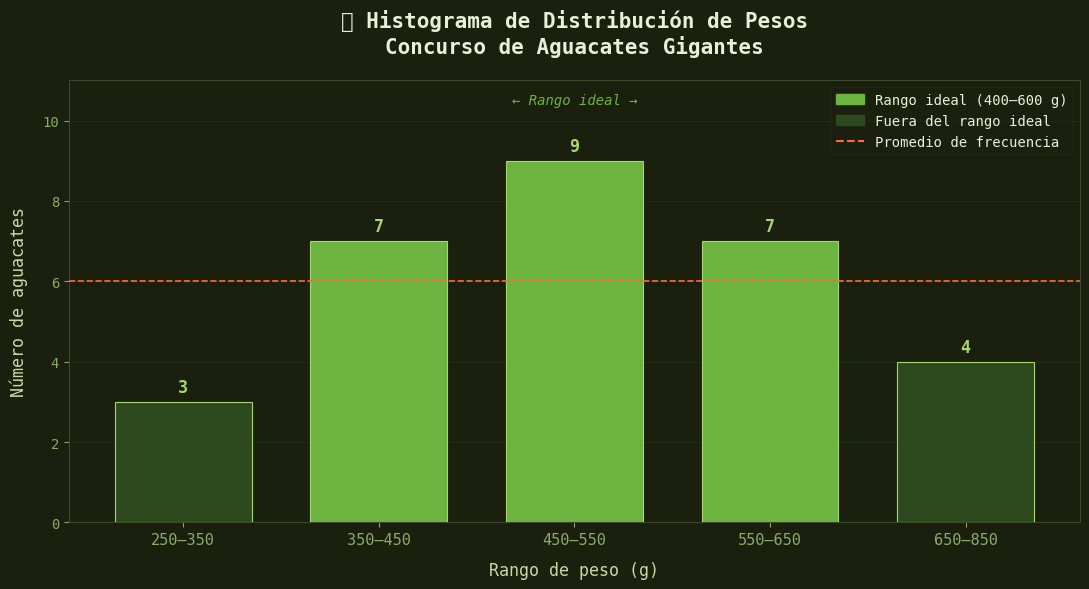

📁 Guardado como: histograma_aguacates.png


In [ ]:
fig, ax = plt.subplots(figsize=(11, 6))

bins = [250, 350, 450, 550, 650, 850]
bin_labels = ['250–350', '350–450', '450–550', '550–650', '650–850']

# Colores: verde brillante si el bin está en zona ideal, verde oscuro si no
counts, edges = np.histogram(pesos, bins=bins)
bar_colors = []
for lo, hi in zip(edges[:-1], edges[1:]):
    overlap = max(0, min(hi, IDEAL_MAX) - max(lo, IDEAL_MIN))
    bar_colors.append('#6DB33F' if overlap > 0 else '#2D4A1E')

bars = ax.bar(
    range(len(counts)), counts,
    color=bar_colors,
    edgecolor='#A8D672',
    linewidth=0.8,
    width=0.7,
    zorder=3
)

# Etiquetas de valor sobre cada barra
for bar, cnt in zip(bars, counts):
    ax.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.15,
        str(cnt),
        ha='center', va='bottom',
        color='#A8D672', fontsize=12, fontweight='bold'
    )

# Líneas de referencia
ax.axhline(y=counts.mean(), color='#FF6B35', linestyle='--', linewidth=1.2,
           label=f'Promedio de frecuencia ({counts.mean():.1f})', zorder=4)

ax.set_xticks(range(len(counts)))
ax.set_xticklabels(bin_labels, fontsize=11)
ax.set_xlabel('Rango de peso (g)', fontsize=12, labelpad=10)
ax.set_ylabel('Número de aguacates', fontsize=12, labelpad=10)
ax.set_title('🥑 Histograma de Distribución de Pesos\nConcurso de Aguacates Gigantes',
             fontsize=15, fontweight='bold', pad=20, color='#e8f0d8')
ax.yaxis.grid(True, zorder=0)
ax.set_axisbelow(True)
ax.set_ylim(0, counts.max() + 2)

# Leyenda
patch_ideal  = mpatches.Patch(color='#6DB33F', label='Rango ideal (400–600 g)')
patch_normal = mpatches.Patch(color='#2D4A1E', label='Fuera del rango ideal')
ax.legend(handles=[patch_ideal, patch_normal,
          plt.Line2D([0],[0], color='#FF6B35', linestyle='--', label='Promedio de frecuencia')],
          loc='upper right', framealpha=0.2, edgecolor='#3a4a2a')

# Anotación del rango ideal
ax.annotate('← Rango ideal →', xy=(2, counts.max() + 1.4),
            ha='center', color='#6DB33F', fontsize=10, style='italic')

plt.tight_layout()
plt.savefig('histograma_aguacates.png', dpi=150, bbox_inches='tight')
plt.show()
print('📁 Guardado como: histograma_aguacates.png')

---
## 📦 Celda 7 — Boxplot con Outliers

/tmp/ipykernel_931/945994455.py:71: UserWarning: Glyph 128230 (\N{PACKAGE}) missing from font(s) DejaVu Sans Mono.
  plt.tight_layout()
/tmp/ipykernel_931/945994455.py:72: UserWarning: Glyph 128230 (\N{PACKAGE}) missing from font(s) DejaVu Sans Mono.
  plt.savefig('boxplot_aguacates.png', dpi=150, bbox_inches='tight')
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128230 (\N{PACKAGE}) missing from font(s) DejaVu Sans Mono.
  fig.canvas.print_figure(bytes_io, **kw)


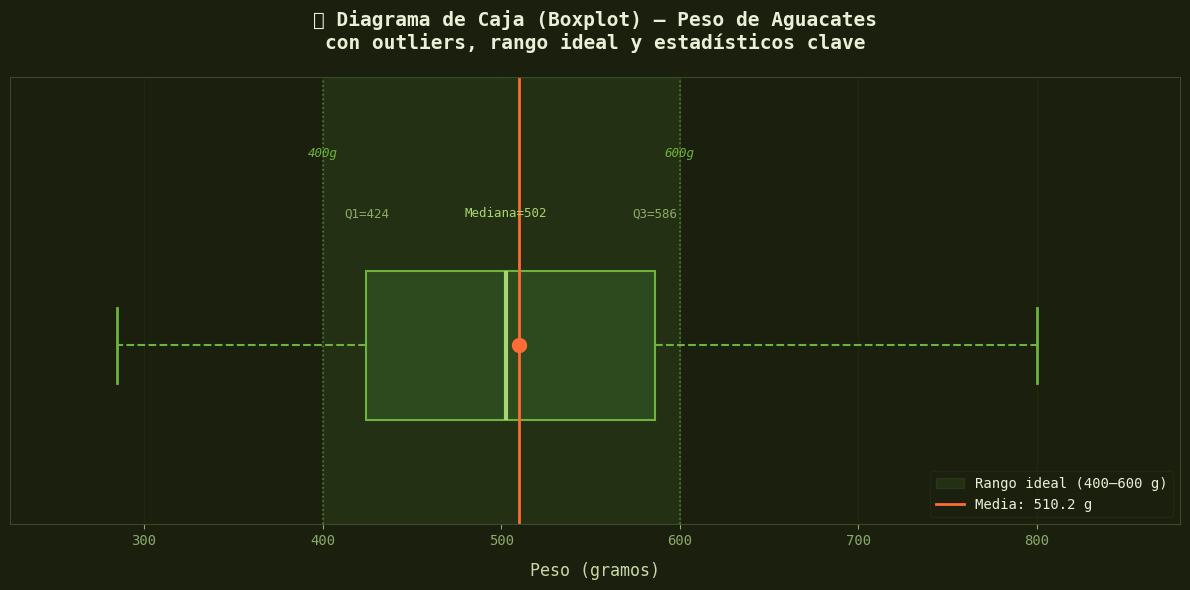

📁 Guardado como: boxplot_aguacates.png

⚡ Cerca inferior : 182.2 g
⚡ Cerca superior  : 828.2 g

🔍 Outliers detectados (0):


In [ ]:
fig, ax = plt.subplots(figsize=(12, 6))

# ── Calcular IQR y cercas ────────────────────────────────────────────────
q1, q3  = pesos.quantile(0.25), pesos.quantile(0.75)
iqr     = q3 - q1
fence_lo = q1 - 1.5 * iqr
fence_hi = q3 + 1.5 * iqr
outlier_mask = (pesos < fence_lo) | (pesos > fence_hi)
outlier_df   = df[outlier_mask]

# ── Boxplot base ─────────────────────────────────────────────────────────
bp = ax.boxplot(
    pesos,
    vert=False,
    patch_artist=True,
    widths=0.5,
    flierprops=dict(marker='D', markersize=10,
                    markerfacecolor='#FF6B35', markeredgecolor='#ffaa88',
                    linestyle='none'),
    medianprops=dict(color='#A8D672', linewidth=3),
    boxprops=dict(facecolor='#2D4A1E', edgecolor='#6DB33F', linewidth=1.5),
    whiskerprops=dict(color='#6DB33F', linewidth=1.5, linestyle='--'),
    capprops=dict(color='#6DB33F', linewidth=2),
)

# ── Zona ideal sombreada ─────────────────────────────────────────────────
ax.axvspan(IDEAL_MIN, IDEAL_MAX, alpha=0.12, color='#6DB33F',
           label=f'Rango ideal ({IDEAL_MIN}–{IDEAL_MAX} g)')
ax.axvline(IDEAL_MIN, color='#6DB33F', linestyle=':', linewidth=1.2, alpha=0.6)
ax.axvline(IDEAL_MAX, color='#6DB33F', linestyle=':', linewidth=1.2, alpha=0.6)

# ── Media ────────────────────────────────────────────────────────────────
ax.axvline(media, color='#FF6B35', linestyle='-', linewidth=2,
           label=f'Media: {media:.1f} g')
ax.scatter(media, 1, color='#FF6B35', s=100, zorder=5)

# ── Etiquetas de outliers ─────────────────────────────────────────────────
for _, row in outlier_df.iterrows():
    offset = 0.28 if row['peso_g'] > fence_hi else -0.28
    ax.annotate(
        f"{row['agricultor']}\n{row['peso_g']}g",
        xy=(row['peso_g'], 1),
        xytext=(row['peso_g'], 1 + offset),
        ha='center', fontsize=9, color='#FF6B35',
        arrowprops=dict(arrowstyle='->', color='#FF6B35', lw=1.2)
    )

# ── Anotaciones estadísticas ──────────────────────────────────────────────
y_ann = 1.42
for val, label, col in [(q1, f'Q1={q1:.0f}', '#8aab6a'),
                         (mediana, f'Mediana={mediana:.0f}', '#A8D672'),
                         (q3, f'Q3={q3:.0f}', '#8aab6a')]:
    ax.text(val, y_ann, label, ha='center', fontsize=9,
            color=col, va='bottom')

# ── Etiquetas rango ideal ─────────────────────────────────────────────────
ax.text(IDEAL_MIN, 1.62, f'{IDEAL_MIN}g', ha='center', fontsize=9,
        color='#6DB33F', va='bottom', style='italic')
ax.text(IDEAL_MAX, 1.62, f'{IDEAL_MAX}g', ha='center', fontsize=9,
        color='#6DB33F', va='bottom', style='italic')

ax.set_yticks([])
ax.set_xlabel('Peso (gramos)', fontsize=12, labelpad=10)
ax.set_title('📦 Diagrama de Caja (Boxplot) — Peso de Aguacates\ncon outliers, rango ideal y estadísticos clave',
             fontsize=14, fontweight='bold', pad=20, color='#e8f0d8')
ax.legend(loc='lower right', framealpha=0.2, edgecolor='#3a4a2a', fontsize=10)
ax.set_xlim(pesos.min() - 60, pesos.max() + 80)
ax.set_ylim(0.4, 1.9)
ax.xaxis.grid(True, alpha=0.3, zorder=0)

plt.tight_layout()
plt.savefig('boxplot_aguacates.png', dpi=150, bbox_inches='tight')
plt.show()
print('📁 Guardado como: boxplot_aguacates.png')

# ── Resumen outliers ─────────────────────────────────────────────────────
print(f'\n⚡ Cerca inferior : {fence_lo:.1f} g')
print(f'⚡ Cerca superior  : {fence_hi:.1f} g')
print(f'\n🔍 Outliers detectados ({len(outlier_df)}):')
for _, row in outlier_df.iterrows():
    tipo = '↑ Muy pesado' if row['peso_g'] > fence_hi else '↓ Muy ligero'
    print(f'   {row["agricultor"]:20s}  {row["peso_g"]} g   {tipo}')

---
## 📋 Celda 8 — Resumen Final Completo

In [ ]:
sep = '═' * 50
print(sep)
print('   🥑  CONCURSO DE AGUACATES GIGANTES — RESUMEN')
print(sep)
print(f'  Total de aguacates           : {len(df)}')
print()
print('  ── ESTADÍSTICOS ─────────────────────────────')
print(f'  Media                        : {media:.2f} g')
print(f'  Mediana                      : {mediana:.2f} g')
print(f'  Moda                         : {moda_val} g')
print(f'  Desviación estándar          : {desv_std:.2f} g')
print(f'  Coeficiente de variación     : {cv:.2f}%  → {cv_interp}')
print(f'  Rango                        : {rango} g')
print()
print('  ── EXTREMOS ─────────────────────────────────')
print(f'  Más pesado  🏆  {mas_pesado["agricultor"]:20s} {mas_pesado["peso_g"]} g')
print(f'  Más ligero  🪶  {mas_ligero["agricultor"]:20s} {mas_ligero["peso_g"]} g')
print()
print('  ── RANGO IDEAL (400–600 g) ──────────────────')
print(f'  Aguacates en rango ideal     : {n_ideal} de {len(df)}  ({pct:.1f}%)')
print()
print('  ── OUTLIERS (IQR × 1.5) ─────────────────────')
if len(outlier_df) == 0:
    print('  Sin valores atípicos detectados ✅')
else:
    for _, row in outlier_df.iterrows():
        t = '↑' if row['peso_g'] > fence_hi else '↓'
        print(f'  {t} {row["agricultor"]:22s} {row["peso_g"]} g')
print(sep)

══════════════════════════════════════════════════
   🥑  CONCURSO DE AGUACATES GIGANTES — RESUMEN
══════════════════════════════════════════════════
  Total de aguacates           : 30

  ── ESTADÍSTICOS ─────────────────────────────
  Media                        : 510.17 g
  Mediana                      : 502.50 g
  Moda                         : 285 g
  Desviación estándar          : 120.56 g
  Coeficiente de variación     : 23.63%  → ⚡ Homogeneidad moderada
  Rango                        : 515 g

  ── EXTREMOS ─────────────────────────────────
  Más pesado  🏆  Los Pinos            800 g
  Más ligero  🪶  El Roble             285 g

  ── RANGO IDEAL (400–600 g) ──────────────────
  Aguacates en rango ideal     : 19 de 30  (63.3%)

  ── OUTLIERS (IQR × 1.5) ─────────────────────
  Sin valores atípicos detectados ✅
══════════════════════════════════════════════════


---
## 📄 Celda 9 — Tabla Completa Clasificada

In [ ]:
# Tabla con estilos de color (solo se ve bien en Jupyter/Colab)
df_display = df[['agricultor', 'peso_g', 'clasificacion']].copy()
df_display.columns = ['Agricultor', 'Peso (g)', 'Clasificación']

def colorear_fila(row):
    color_map = {
        'Rango ideal ✅':        'background-color: #1f3a12; color: #A8D672',
        'Por encima del ideal':  'background-color: #1a2a0e; color: #c8d8a8',
        'Por debajo del ideal':  'background-color: #2a1a08; color: #d4a070',
    }
    return [color_map.get(row['Clasificación'], '') for _ in row]

df_display.style\
    .apply(colorear_fila, axis=1)\
    .set_properties(**{'border': '1px solid #3a4a2a', 'padding': '6px 12px'})\
    .set_table_styles([{'selector': 'th', 'props': [
        ('background-color', '#2D4A1E'), ('color', '#A8D672'),
        ('font-weight', 'bold'), ('padding', '8px 14px')
    ]}])\
    .format({'Peso (g)': '{:.0f} g'})

,Agricultor,Peso (g),Clasificación
1,Los Pinos,800 g,Por encima del ideal
2,Finca Serena,720 g,Por encima del ideal
3,Campo Grande,690 g,Por encima del ideal
4,Monte Alto,670 g,Por encima del ideal
5,Finca Santa Ana,625 g,Por encima del ideal
6,Huerta Milagros,610 g,Por encima del ideal
7,Flor del Campo,600 g,Rango ideal ✅
8,Finca La Verde,588 g,Rango ideal ✅
9,Jardín Eterno,580 g,Rango ideal ✅
10,Tierra Viva,565 g,Rango ideal ✅
